In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (나눔바른고딕 사용)
plt.rc('font', family='NanumBarunGothic')
# 마이너스 기호(-)가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# --- [1단계] 데이터 로드 (최신 코랩 방식) ---
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
X_raw = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y_raw = raw_df.values[1::2, 2].reshape(-1, 1)

# 데이터 증폭 (1000개 이상으로 만들기 위해 4배 복사)
X = np.tile(X_raw, (4, 1))
y = np.tile(y_raw, (4, 1))

In [4]:
# --- [2단계] 전처리 (표준화) ---
# 경사 하강법의 안정적인 수렴을 위해 데이터를 표준화.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 편향(Bias) 항을 위해 1로 채워진 열을 맨 앞에 추가합니다. (x0 = 1)
X_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

In [5]:
# --- [3단계] 경사 하강법 함수 정의 ---
def run_gradient_descent(X, y, mode='batch', lr=0.01, iterations=50, batch_size=32):
    m = len(y)
    # 가중치(theta)를 무작위로 초기화
    theta = np.random.randn(X.shape[1], 1)
    # 학습 과정을 기록하기 위한 리스트
    cost_history = []

    for i in range(iterations):
        if mode == 'batch':
          # 1) 배치 경사 하강법: 전체 데이터를 사용하여 기울기 계산
            gradients = 2/m * X.T.dot(X.dot(theta) - y)
            theta = theta - lr * gradients

        elif mode == 'sgd':
          # 2) 확률적 경사 하강법: 매 단계 무작위 데이터 1개만 사용
            for _ in range(m):
                idx = np.random.randint(m)
                xi, yi = X[idx:idx+1], y[idx:idx+1]
                gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
                theta = theta - lr * gradients

        elif mode == 'minibatch':
          # 3) 미니 배치 경사 하강법: 데이터를 작은 묶음(배치) 단위로 사용
            indices = np.random.permutation(m)
            X_s, y_s = X[indices], y[indices]
            for j in range(0, m, batch_size):
                xi, yi = X_s[j:j+batch_size], y_s[j:j+batch_size]
                gradients = 2/len(xi) * xi.T.dot(xi.dot(theta) - yi)
                theta = theta - lr * gradients

        # 현재 에포크의 평균 제곱 오차(MSE) 계산 및 기록
        cost = np.mean(np.square(X.dot(theta) - y))
        cost_history.append(cost)
    return cost_history

In [6]:
# --- [4단계] 실행 및 결과 확인 ---
print("03/21 미션 학습 중...")
# 배치 방식 실행
hist_batch = run_gradient_descent(X_b, y, mode='batch', lr=0.01)
# 확률적 방식 실행 (안정성을 위해 학습률을 낮게 설정)
hist_sgd = run_gradient_descent(X_b, y, mode='sgd', lr=0.0005)
# 미니 배치 방식 실행
hist_mini = run_gradient_descent(X_b, y, mode='minibatch', lr=0.01)
print("학습 완료!")

03/21 미션 학습 중...
학습 완료!


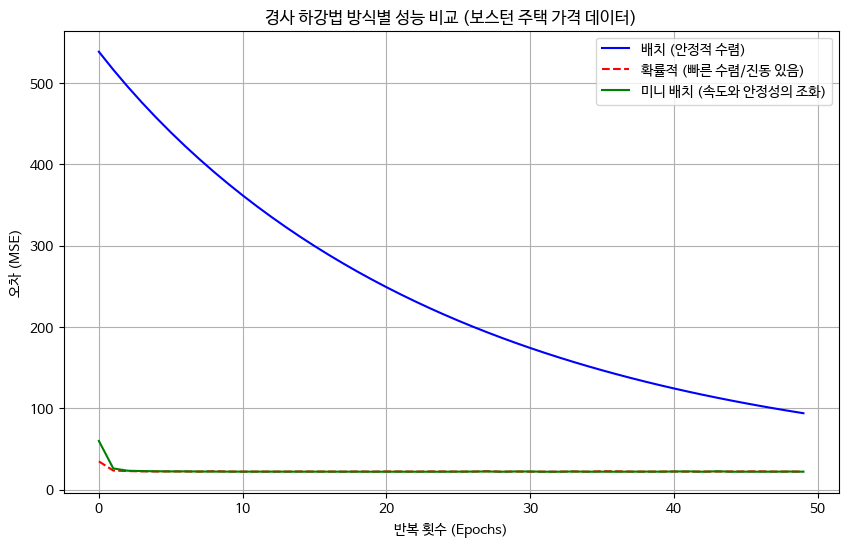

In [7]:
# --- [5단계] 시각화 ---
plt.figure(figsize=(10, 6))
plt.plot(hist_batch, "b-", label="배치 (안정적 수렴)")
plt.plot(hist_sgd, "r--", label="확률적 (빠른 수렴/진동 있음)")
plt.plot(hist_mini, "g-", label="미니 배치 (속도와 안정성의 조화)")

plt.title("경사 하강법 방식별 성능 비교 (보스턴 주택 가격 데이터)")
plt.xlabel("반복 횟수 (Epochs)")
plt.ylabel("오차 (MSE)")
plt.legend()
plt.grid(True)
plt.show()